In [26]:
import mne
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

mne.set_log_level('WARNING')

In [1]:
import mne
import os
from pathlib import Path

# 1. Define the path to the raw data folder
# Note: We use '../' because this .ipynb file is located inside the 'notebooks' folder, 
# so we need to step back one directory level to access the 'data' folder.
raw_dir = Path('../data/raw/bigp3bci')

# 2. Find ALL .edf files, but we will grab just the FIRST one [0] for our experiment
all_files = list(raw_dir.rglob('*.edf'))
sample_file = all_files[0] 

print(f"📁 Examining sample file: {sample_file.name}\n")

# 3. Open the file LAZILY (preload=False) to prevent RAM from crashing
raw = mne.io.read_raw_edf(sample_file, preload=False, verbose=False)

# 4. Display Medical Summary / Metadata
print("=== EEG METADATA INFORMATION ===")
print(f"🔹 Total Channels       : {len(raw.ch_names)} electrodes")
print(f"🔹 First 10 Channels    : {raw.ch_names[:10]}")
print(f"🔹 Sampling Frequency   : {raw.info['sfreq']} Hz (Data points captured per second)")
print(f"🔹 Total Recording Time : {raw.times[-1] / 60:.2f} minutes")

# 5. Peek into the built-in MNE 'info' object
print("\n=== RAW.INFO DETAILS ===")
print(raw.info)

📁 Examining sample file: A_01_SE001_CB_Test06.edf



C:\Users\sagita pra kosa\AppData\Local\Temp\ipykernel_3880\1934402762.py:17: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(sample_file, preload=False, verbose=False)
C:\Users\sagita pra kosa\AppData\Local\Temp\ipykernel_3880\1934402762.py:17: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(sample_file, preload=False, verbose=False)


=== EEG METADATA INFORMATION ===
🔹 Total Channels       : 114 electrodes
🔹 First 10 Channels    : ['EEG_F3', 'EEG_Fz', 'EEG_F4', 'EEG_T7', 'EEG_C3', 'EEG_Cz', 'EEG_C4', 'EEG_T8', 'EEG_CP3', 'EEG_CP4']
🔹 Sampling Frequency   : 256.0000930697907 Hz (Data points captured per second)
🔹 Total Recording Time : 2.29 minutes

=== RAW.INFO DETAILS ===
<Info | 8 non-empty values
 bads: []
 ch_names: EEG_F3, EEG_Fz, EEG_F4, EEG_T7, EEG_C3, EEG_Cz, EEG_C4, EEG_T8, ...
 chs: 114 EEG
 custom_ref_applied: False
 highpass: 58.0 Hz
 lowpass: 62.0 Hz
 meas_date: 2020-01-01 00:00:00 UTC
 nchan: 114
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: A_01, sex: 0, first_name: X, last_name: X, birthday: 2020-01-01>
>


In [28]:
data_dir = Path("../data/raw/bigp3bci/bigP3BCI-data")

edf_files = list(data_dir.rglob("*.edf"))

print(f"Total EDF files: {len(edf_files)}")

sample_file = edf_files[0]
print("Sample file:", sample_file)

Total EDF files: 6980
Sample file: ..\data\raw\bigp3bci\bigP3BCI-data\StudyA\A_01\SE001\Test\CB\A_01_SE001_CB_Test06.edf


In [29]:
import warnings
warnings.filterwarnings("ignore")
raw = mne.io.read_raw_edf(sample_file.as_posix(), preload=True)
raw

<RawEDF | A_01_SE001_CB_Test06.edf, 114 x 35208 (137.5 s), ~30.7 MiB, data loaded>

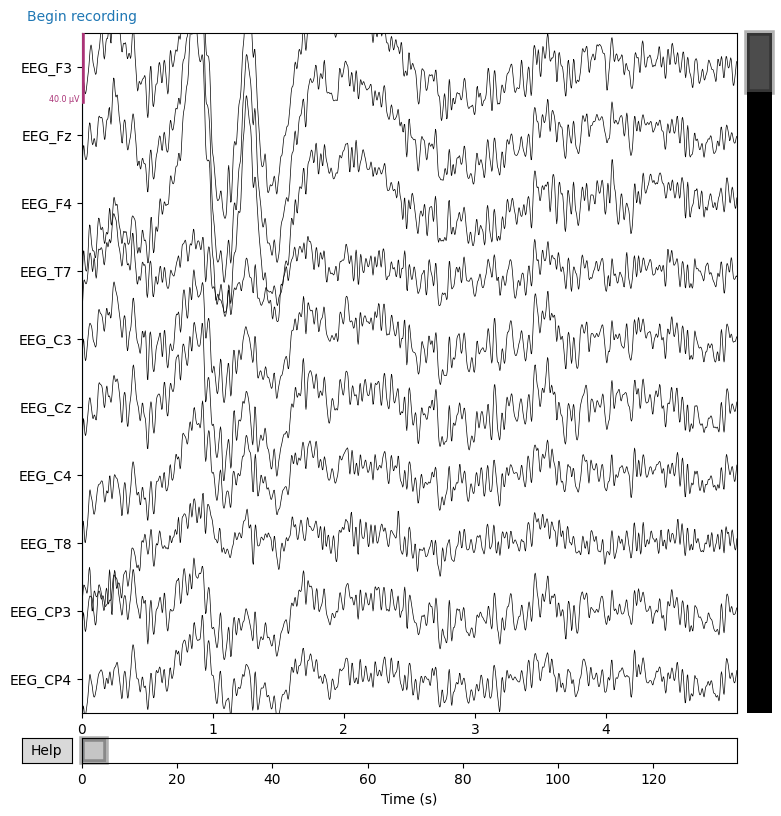

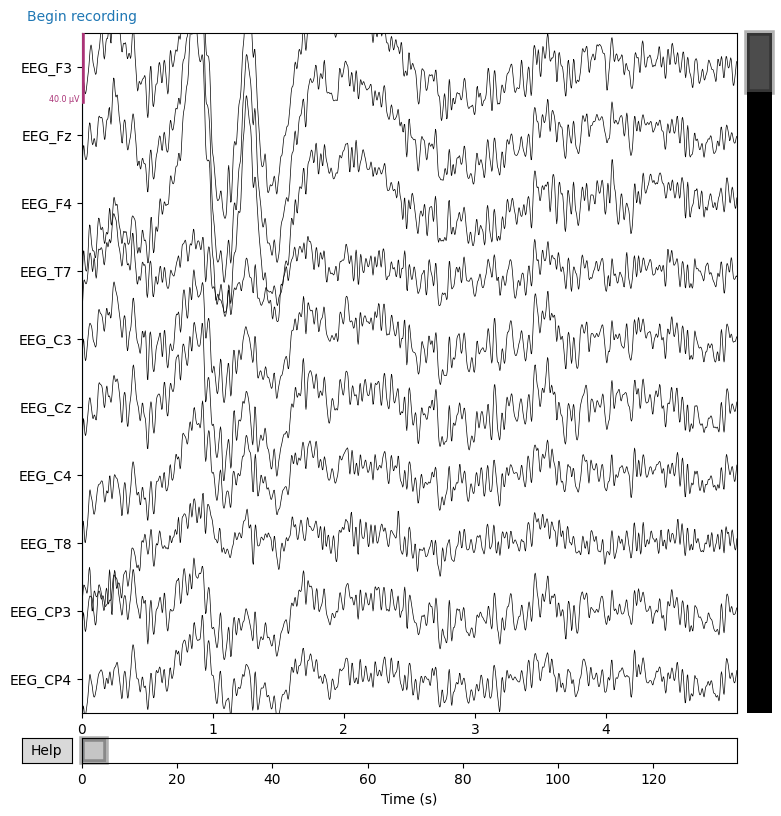

In [30]:
raw.plot(n_channels=10, duration=5)

In [31]:
events = mne.find_events(raw, stim_channel='StimulusBegin')
print("Jumlah event:", len(events))

Jumlah event: 840


In [32]:
stim = raw.get_data(picks=['StimulusType'])[0]
labels = stim[events[:, 0]].astype(int)

print("Contoh label:", labels[:20])

Contoh label: [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]


In [33]:
ch_p300 = [
    'EEG_Fz', 'EEG_Cz', 'EEG_Pz',
    'EEG_P3', 'EEG_P4',
    'EEG_PO7', 'EEG_PO8', 'EEG_Oz'
]

raw_filtered = raw.copy().pick(ch_p300)
raw_filtered.filter(0.1, 30.0)

<RawEDF | A_01_SE001_CB_Test06.edf, 8 x 35208 (137.5 s), ~2.2 MiB, data loaded>

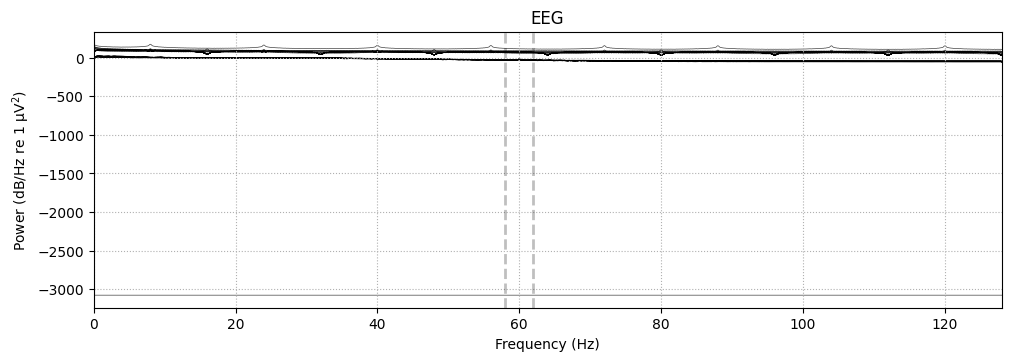

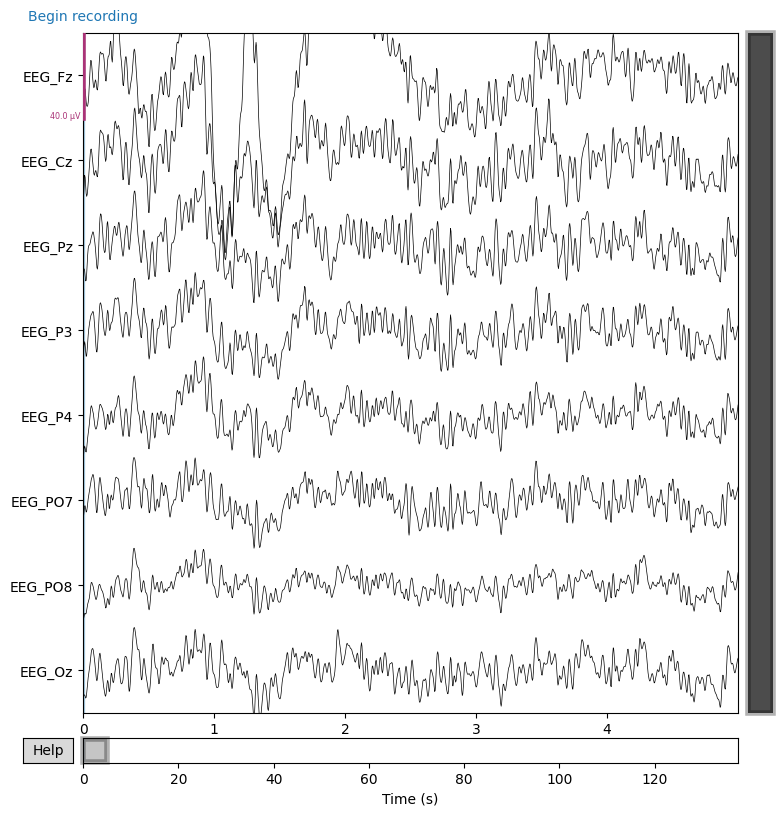

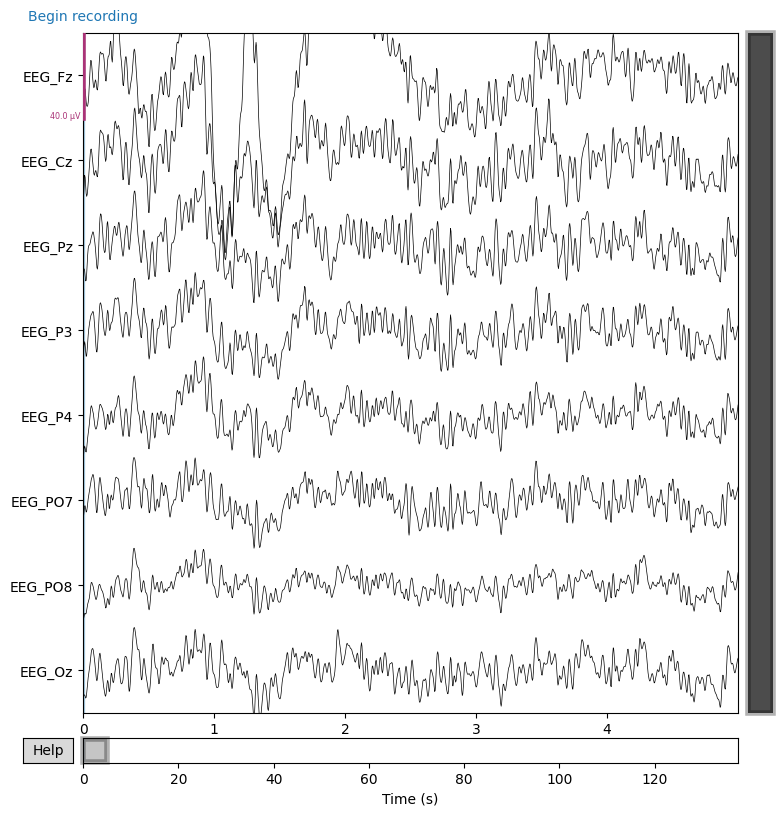

In [25]:
raw_filtered.plot(n_channels=8, duration=5)

In [9]:
epochs = mne.Epochs(
    raw_filtered,
    events,
    picks=ch_p300,
    tmin=-0.2,
    tmax=0.8,
    baseline=(None, 0),
    preload=True
)

epochs

<Epochs | 840 events (all good), -0.199 – 0.801 s (baseline -0.199 – 0 s), ~13.2 MiB, data loaded,
 '1': 840>

In [10]:
epochs.resample(128)

<Epochs | 840 events (all good), -0.199 – 0.793 s (baseline -0.199 – 0 s), ~6.6 MiB, data loaded,
 '1': 840>

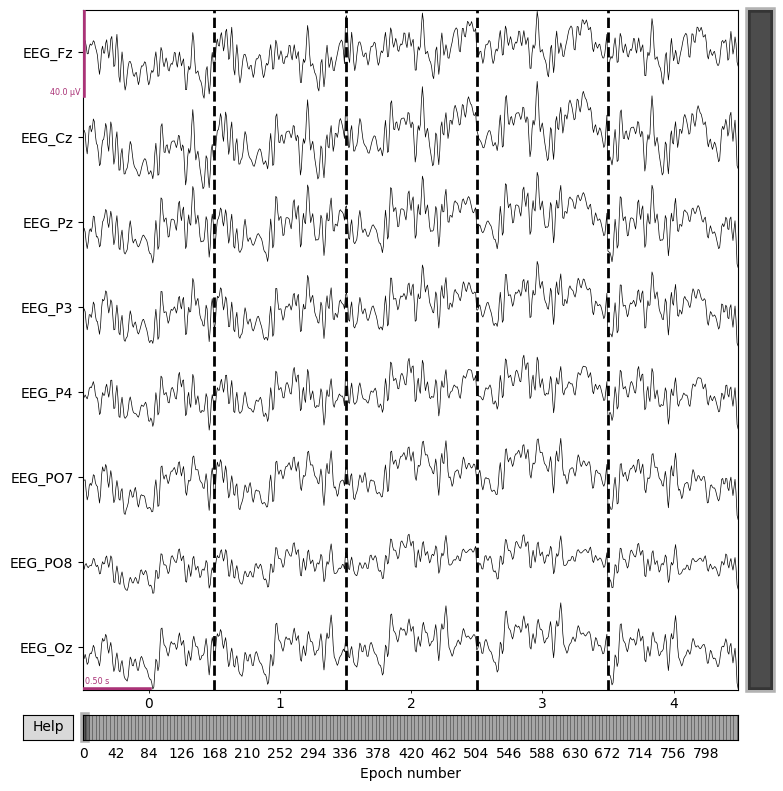

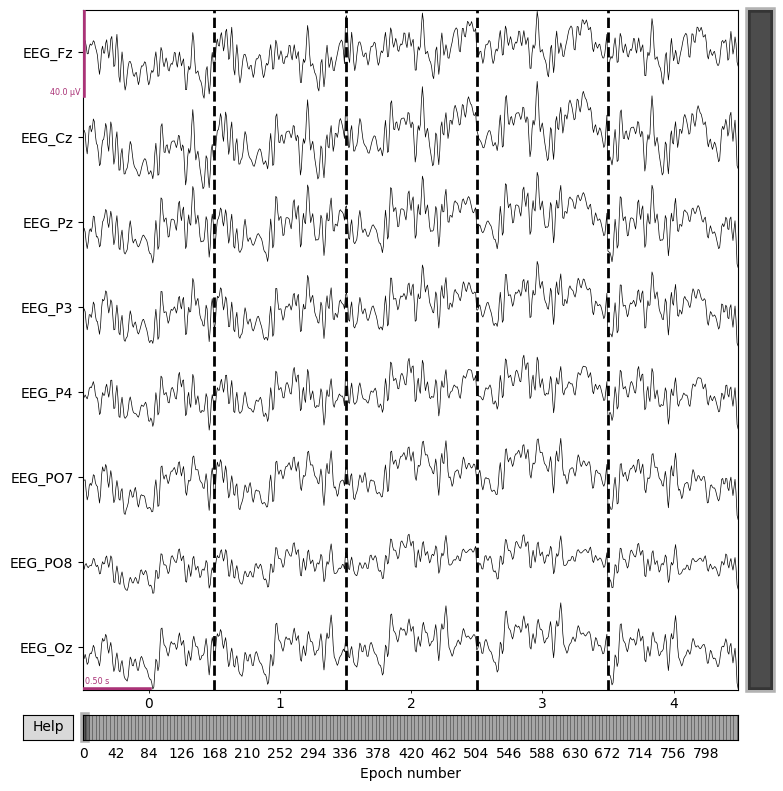

In [11]:
epochs.plot(n_epochs=5)

In [13]:
X = epochs.get_data()
Y = labels

print("Shape X:", X.shape)
print("Shape Y:", Y.shape)

Shape X: (840, 8, 128)
Shape Y: (840,)


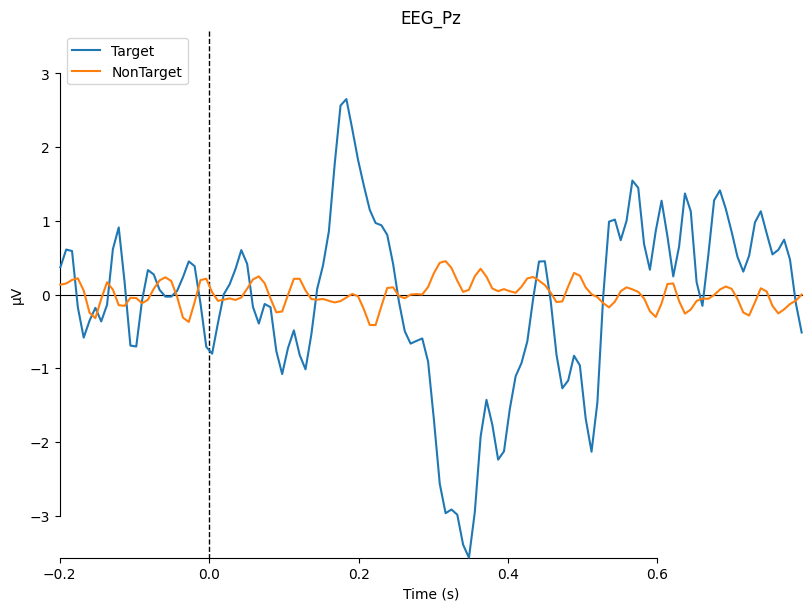

[<Figure size 800x600 with 1 Axes>]

In [14]:
target_epochs = epochs[Y == 1]
nontarget_epochs = epochs[Y == 0]

target_avg = target_epochs.average()
nontarget_avg = nontarget_epochs.average()

mne.viz.plot_compare_evokeds(
    dict(Target=target_avg, NonTarget=nontarget_avg),
    picks='EEG_Pz'
)

In [17]:
# labels sudah Anda punya sebelumnya
# 1 = target, 0 = non-target (sesuaikan jika berbeda)

target_epochs = epochs[labels == 1]
nontarget_epochs = epochs[labels == 0]

print("Target:", len(target_epochs))
print("Non-target:", len(nontarget_epochs))

Target: 70
Non-target: 770


In [18]:
target_evoked = target_epochs.average()
nontarget_evoked = nontarget_epochs.average()

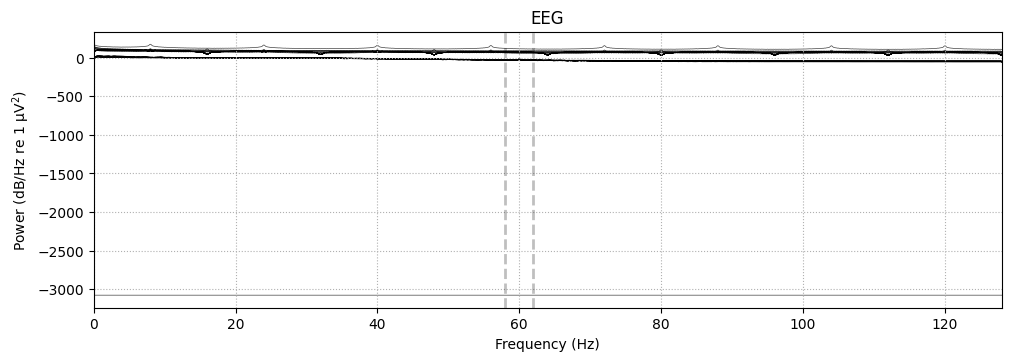

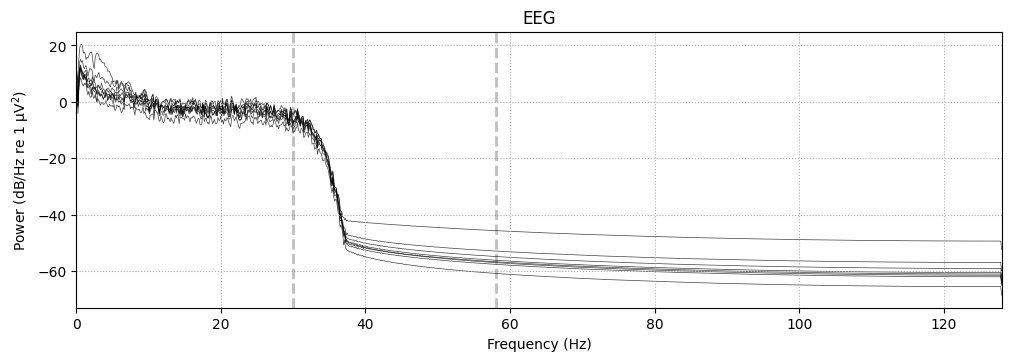

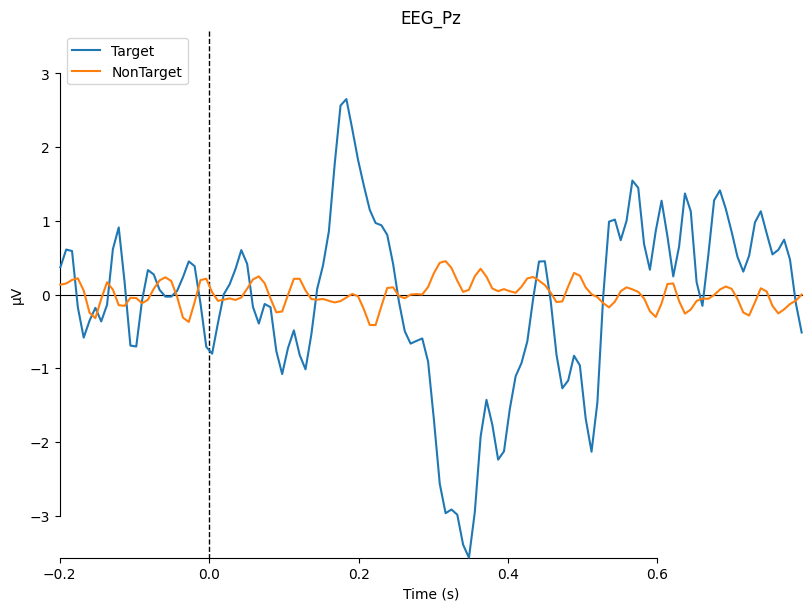

[<Figure size 800x600 with 1 Axes>]

In [19]:
mne.viz.plot_compare_evokeds(
    dict(Target=target_evoked, NonTarget=nontarget_evoked),
    picks='EEG_Pz'
)